In [8]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")
print("Setup complete - ready to process Borda count rankings")


Libraries imported successfully!
Setup complete - ready to process Borda count rankings


In [48]:
# Load your evaluation data
def load_evaluation_data(file_path=None):
    """
    Load evaluation data from JSON file or use sample data for testing
    """
    if file_path:
        with open(file_path, 'r') as f:
            data = json.load(f)
        print(f"✓ Data loaded from {file_path}")
    else:
        # Use the sample data from the document (you can replace this with your actual data)
        print("⚠ Using sample data - replace with your actual file path")
        data = {
            "all_user_results": [
                {
                    "user_id": "U83578",
                    "target_item": "Rip Taylor's Cause of Death Revealed, Memorial Service Scheduled for Later This Month[Category:tv,Subcategory:tvnews]",
                    "user_history": [
                        "Orangutan granted legal personhood moves to Florida[Category:news,Subcategory:newsus]",
                        "'I am scared all the time': Chimps and people are clashing in rural Uganda[Category:news,Subcategory:newsworld]",
                        "Kendall Jenner Wore the Tiniest Dress to Go Jewelry Shopping[Category:lifestyle,Subcategory:lifestylebuzz]",
                        "Next week's Arctic blast will be so cold, forecasters expect it to break 170 records across US[Category:weather,Subcategory:weathertopstories]",
                        "MLB Silver Slugger Award winners for 2019 season announced[Category:sports,Subcategory:baseball_mlb]"
                    ],
                    "accuracy": 0.0,
                    "ndcg_1": 0.0,
                    "ndcg_5": 0.43067655807339306,
                    "ndcg_10": 0.43067655807339306,
                    "ndcg_20": 0.43067655807339306,
                    "raw_llm_data": []  # Will be populated with actual trial data
                }
            ]
        }
    
    return data

# Load data - replace None with your file path
evaluation_data = load_evaluation_data('./evaluation_checkpoint_books.json')

# Inspect the data structure
print(f"\nData Overview:")
print(f"Number of users: {len(evaluation_data['all_user_results'])}")
for i, user in enumerate(evaluation_data['all_user_results'][:3]):  # Show first 3 users
    print(f"User {i+1}: {user['user_id']}")
    print(f"  Target item: {user['target_item'][:50]}...")
    print(f"  Number of trials: {len(user.get('raw_llm_data', []))}")
    print(f"  Original NDCG@5: {user.get('ndcg_5', 'N/A')}")

✓ Data loaded from ./evaluation_checkpoint_books.json

Data Overview:
Number of users: 200
User 1: A27HCDWXKTI0KA
  Target item: The Twilight Zone Companion...
  Number of trials: 20
  Original NDCG@5: 0.38685280723454163
User 2: AMS6J2UF82NN2
  Target item: Last Woman...
  Number of trials: 20
  Original NDCG@5: 0.0
User 3: A56U3JJ96FK3J
  Target item: Strange Candy...
  Number of trials: 20
  Original NDCG@5: 0.0


In [49]:
def apply_borda_count_ranking(evaluation_data):
    """
    Apply Borda count ranking based on debiased scores from multiple trials.
    """
    results = {}
    
    for user_result in evaluation_data["all_user_results"]:
        user_id = user_result["user_id"]
        raw_llm_data = user_result.get("raw_llm_data", [])
        
        if not raw_llm_data:
            print(f"⚠ No trial data found for user {user_id}")
            continue
        
        # Dictionary to store cumulative Borda scores
        borda_scores = defaultdict(float)
        title_info = {}
        
        print(f"Processing user {user_id} with {len(raw_llm_data)} trials...")
        
        # Process each trial
        for trial_idx, trial in enumerate(raw_llm_data):
            trial_scores = []
            
            for candidate in trial["original_candidate_list"]:
                title = candidate["title"]
                if "debiased_score" not in candidate:
                    debiased_score = 0
                else:
                    debiased_score = candidate["debiased_score"]
                original_pos = candidate["original_position"]
                
                trial_scores.append({
                    "title": title,
                    "debiased_score": debiased_score,
                    "original_position": original_pos
                })
                
                # Extract category information
                if "[Category:" in title:
                    category = title.split("[Category:")[-1].split(",")[0]
                else:
                    category = "unknown"
                
                title_info[title] = {
                    "original_position": original_pos,
                    "category": category
                }
            
            # Sort by debiased score (descending - higher is better)
            trial_scores.sort(key=lambda x: x["debiased_score"], reverse=True)
            
            # Apply Borda count scoring
            num_candidates = len(trial_scores)
            for rank, item in enumerate(trial_scores):
                borda_score = num_candidates - rank
                borda_scores[item["title"]] += borda_score
        
        # Calculate final rankings
        num_trials = len(raw_llm_data)
        final_rankings = []
        
        for title, total_borda_score in borda_scores.items():
            avg_borda_score = total_borda_score / num_trials
            final_rankings.append({
                "title": title,
                "average_borda_score": avg_borda_score,
                "total_borda_score": total_borda_score,
                "original_position": title_info[title]["original_position"],
                "category": title_info[title]["category"],
                "title_short": title.split("[Category:")[0][:50] + "..." if len(title.split("[Category:")[0]) > 50 else title.split("[Category:")[0]
            })
        
        # Sort by average Borda score (descending)
        final_rankings.sort(key=lambda x: x["average_borda_score"], reverse=True)
        
        # Add final ranking positions
        for i, item in enumerate(final_rankings):
            item["final_borda_rank"] = i + 1
            item["position_change"] = item["original_position"] - item["final_borda_rank"]
        
        results[user_id] = {
            "target_item": user_result["target_item"],
            "user_history": user_result["user_history"],
            "final_rankings": final_rankings,
            "num_trials": num_trials,
            "original_metrics": {
                "accuracy": user_result.get("accuracy", 0),
                "ndcg_1": user_result.get("ndcg_1", 0),
                "ndcg_5": user_result.get("ndcg_5", 0),
                "ndcg_10": user_result.get("ndcg_10", 0),
                "ndcg_20": user_result.get("ndcg_20", 0)
            }
        }
    
    return results

# Apply Borda count ranking
print("Applying Borda count ranking...")
borda_results = apply_borda_count_ranking(evaluation_data)
print(f"✓ Borda count completed for {len(borda_results)} users")

Applying Borda count ranking...
Processing user A27HCDWXKTI0KA with 20 trials...
Processing user AMS6J2UF82NN2 with 20 trials...
Processing user A56U3JJ96FK3J with 20 trials...
Processing user AXVBGNJDUVPVA with 20 trials...
Processing user A2UWG77YW8T2M with 20 trials...
Processing user A2GMF57QX2XKQU with 20 trials...
Processing user A9F8MY28BOO1D with 20 trials...
Processing user A3GSRO8H4WMICB with 20 trials...
Processing user AQYM7Q42F4C87 with 20 trials...
Processing user A3UM6L2OK9KKW4 with 20 trials...
Processing user A8HH3AZAAZDV4 with 20 trials...
Processing user A1YC6XVUUNCTC with 20 trials...
Processing user AX41TTHQLWY70 with 20 trials...
Processing user A3MM7I7Y88ENY2 with 20 trials...
Processing user A23MBQRAQ9TKI6 with 20 trials...
Processing user A12OALV7NUI50 with 20 trials...
Processing user A2SRV4G52JNYQR with 20 trials...
Processing user A2J7FXEJ7NVGA1 with 20 trials...
Processing user A3BV7IECJ49FUE with 20 trials...
Processing user A1KXP5YXAPHFM1 with 20 trials..

In [50]:
def analyze_borda_results(borda_results):
    """
    Comprehensive analysis of Borda count results
    """
    analysis = {}
    
    for user_id, user_data in borda_results.items():
        rankings = user_data["final_rankings"]
        target_item = user_data["target_item"]
        
        # Find target item rank
        target_rank = None
        target_borda_score = None
        for item in rankings:
            if item["title"] == target_item:
                target_rank = item["final_borda_rank"]
                target_borda_score = item["average_borda_score"]
                break
        
        # Category analysis
        all_categories = [item["category"] for item in rankings]
        top_5_categories = [item["category"] for item in rankings[:5]]
        
        # Position change analysis
        position_changes = [item["position_change"] for item in rankings]
        
        # Top performers
        top_item = rankings[0] if rankings else None
        
        analysis[user_id] = {
            "target_item_rank": target_rank,
            "target_item_borda_score": target_borda_score,
            "target_item_found": target_rank is not None,
            "top_5_categories": Counter(top_5_categories),
            "all_categories": Counter(all_categories),
            "position_changes": position_changes,
            "avg_position_change": np.mean(position_changes),
            "top_item": top_item,
            "num_items": len(rankings)
        }
    
    return analysis

# Perform analysis
print("Analyzing Borda count results...")
analysis = analyze_borda_results(borda_results)

# Display summary statistics
print("\n" + "="*60)
print("BORDA COUNT ANALYSIS SUMMARY")
print("="*60)

for user_id, user_analysis in analysis.items():
    print(f"\n👤 User: {user_id}")
    print(f"   📊 Total items analyzed: {user_analysis['num_items']}")
    print(f"   🎯 Target item rank: {user_analysis['target_item_rank']}")
    if user_analysis['target_item_borda_score']:
        print(f"   📈 Target item Borda score: {user_analysis['target_item_borda_score']:.2f}")
    print(f"   📊 Average position change: {user_analysis['avg_position_change']:+.1f}")
    
    if user_analysis['top_item']:
        print(f"   🏆 Top ranked item: {user_analysis['top_item']['title_short']}")
        print(f"   📈 Top item Borda score: {user_analysis['top_item']['average_borda_score']:.2f}")


Analyzing Borda count results...

BORDA COUNT ANALYSIS SUMMARY

👤 User: A27HCDWXKTI0KA
   📊 Total items analyzed: 20
   🎯 Target item rank: 5
   📈 Target item Borda score: 11.95
   📊 Average position change: -1.0
   🏆 Top ranked item: Solving Crimes: Pioneers of Forensic Science (Live...
   📈 Top item Borda score: 16.15

👤 User: AMS6J2UF82NN2
   📊 Total items analyzed: 20
   🎯 Target item rank: 13
   📈 Target item Borda score: 9.00
   📊 Average position change: -1.0
   🏆 Top ranked item: Bad Medicine: An Ella Clah Novel (Ella Clah Novels...
   📈 Top item Borda score: 15.00

👤 User: A56U3JJ96FK3J
   📊 Total items analyzed: 20
   🎯 Target item rank: 14
   📈 Target item Borda score: 9.10
   📊 Average position change: -1.0
   🏆 Top ranked item: Addicted to Unhappiness: Free Yourself from Moods ...
   📈 Top item Borda score: 16.10

👤 User: AXVBGNJDUVPVA
   📊 Total items analyzed: 20
   🎯 Target item rank: 11
   📈 Target item Borda score: 10.90
   📊 Average position change: -1.0
   🏆 Top ran

In [51]:
def display_detailed_results(borda_results, user_id=None, top_n=10):
    """
    Display detailed results for specific user or all users
    """
    users_to_show = [user_id] if user_id else list(borda_results.keys())
    
    for uid in users_to_show:
        if uid not in borda_results:
            print(f"User {uid} not found!")
            continue
            
        user_data = borda_results[uid]
        print(f"\n{'='*80}")
        print(f"DETAILED RESULTS FOR USER: {uid}")
        print(f"{'='*80}")
        
        print(f"🎯 Target Item: {user_data['target_item']}")
        print(f"📊 Number of trials: {user_data['num_trials']}")
        print(f"📈 Original NDCG@5: {user_data['original_metrics']['ndcg_5']:.4f}")
        
        print(f"\n📋 TOP {top_n} BORDA RANKINGS:")
        print("-" * 80)
        
        for i, item in enumerate(user_data["final_rankings"][:top_n]):
            is_target = "🎯" if item["title"] == user_data["target_item"] else "  "
            change_icon = "📈" if item["position_change"] > 0 else "📉" if item["position_change"] < 0 else "➡️"
            
            print(f"{is_target} {i+1:2d}. {item['title_short']}")
            print(f"      Category: {item['category']}")
            print(f"      Borda Score: {item['average_borda_score']:.2f}")
            print(f"      Position: {item['original_position']} → {item['final_borda_rank']} {change_icon} ({item['position_change']:+d})")
            print()

# Display results for all users
display_detailed_results(borda_results)


DETAILED RESULTS FOR USER: A27HCDWXKTI0KA
🎯 Target Item: The Twilight Zone Companion
📊 Number of trials: 20
📈 Original NDCG@5: 0.3869

📋 TOP 10 BORDA RANKINGS:
--------------------------------------------------------------------------------
    1. Solving Crimes: Pioneers of Forensic Science (Live...
      Category: unknown
      Borda Score: 16.15
      Position: 2 → 1 📈 (+1)

    2. Uneasy in Babylon: Southern Baptist Conservatives ...
      Category: unknown
      Borda Score: 14.60
      Position: 0 → 2 📉 (-2)

    3. Echoes of My African Heart: An Odyssey of Life and...
      Category: unknown
      Borda Score: 13.65
      Position: 7 → 3 📈 (+4)

    4. Naval Chronicles: The Naval Chronicle: The Contemp...
      Category: unknown
      Borda Score: 13.05
      Position: 3 → 4 📉 (-1)

🎯  5. The Twilight Zone Companion
      Category: unknown
      Borda Score: 11.95
      Position: 12 → 5 📈 (+7)

    6. I Saw France Fall, Will She Rise Again?
      Category: unknown
      Borda S

In [52]:
def create_results_dataframe(borda_results):
    """
    Create a comprehensive DataFrame from Borda results
    """
    all_rankings = []
    
    for user_id, user_data in borda_results.items():
        for item in user_data["final_rankings"]:
            all_rankings.append({
                "user_id": user_id,
                "title": item["title"],
                "title_short": item["title_short"],
                "category": item["category"],
                "final_borda_rank": item["final_borda_rank"],
                "average_borda_score": item["average_borda_score"],
                "total_borda_score": item["total_borda_score"],
                "original_position": item["original_position"],
                "position_change": item["position_change"],
                "is_target": item["title"] == borda_results[user_id]["target_item"],
                "num_trials": user_data["num_trials"],
                "original_ndcg_5": user_data["original_metrics"]["ndcg_5"]
            })
    
    return pd.DataFrame(all_rankings)

df_results = create_results_dataframe(borda_results)

print("📊 Results DataFrame created!")
print(f"   Shape: {df_results.shape}")
print(f"   Columns: {list(df_results.columns)}")

# Display sample data
print("\n📋 Sample of results:")
print(df_results.head(10)[['user_id', 'title_short', 'final_borda_rank', 'average_borda_score', 'position_change', 'is_target']])

# Export to CSV
csv_filename = "borda_count_rankings.csv"
df_results.to_csv(csv_filename, index=False)
print(f"\n💾 Results exported to: {csv_filename}")

📊 Results DataFrame created!
   Shape: (4000, 12)
   Columns: ['user_id', 'title', 'title_short', 'category', 'final_borda_rank', 'average_borda_score', 'total_borda_score', 'original_position', 'position_change', 'is_target', 'num_trials', 'original_ndcg_5']

📋 Sample of results:
          user_id                                        title_short  \
0  A27HCDWXKTI0KA  Solving Crimes: Pioneers of Forensic Science (...   
1  A27HCDWXKTI0KA  Uneasy in Babylon: Southern Baptist Conservati...   
2  A27HCDWXKTI0KA  Echoes of My African Heart: An Odyssey of Life...   
3  A27HCDWXKTI0KA  Naval Chronicles: The Naval Chronicle: The Con...   
4  A27HCDWXKTI0KA                        The Twilight Zone Companion   
5  A27HCDWXKTI0KA            I Saw France Fall, Will She Rise Again?   
6  A27HCDWXKTI0KA  Bobby Flay's Mesa Grill Cookbook: Explosive Fl...   
7  A27HCDWXKTI0KA  Anita Blake: Vampire Hunter Boxed Set: Guilty ...   
8  A27HCDWXKTI0KA     Sensei : the life story of Irene Webster-Smith  

🎨 Creating visualizations...


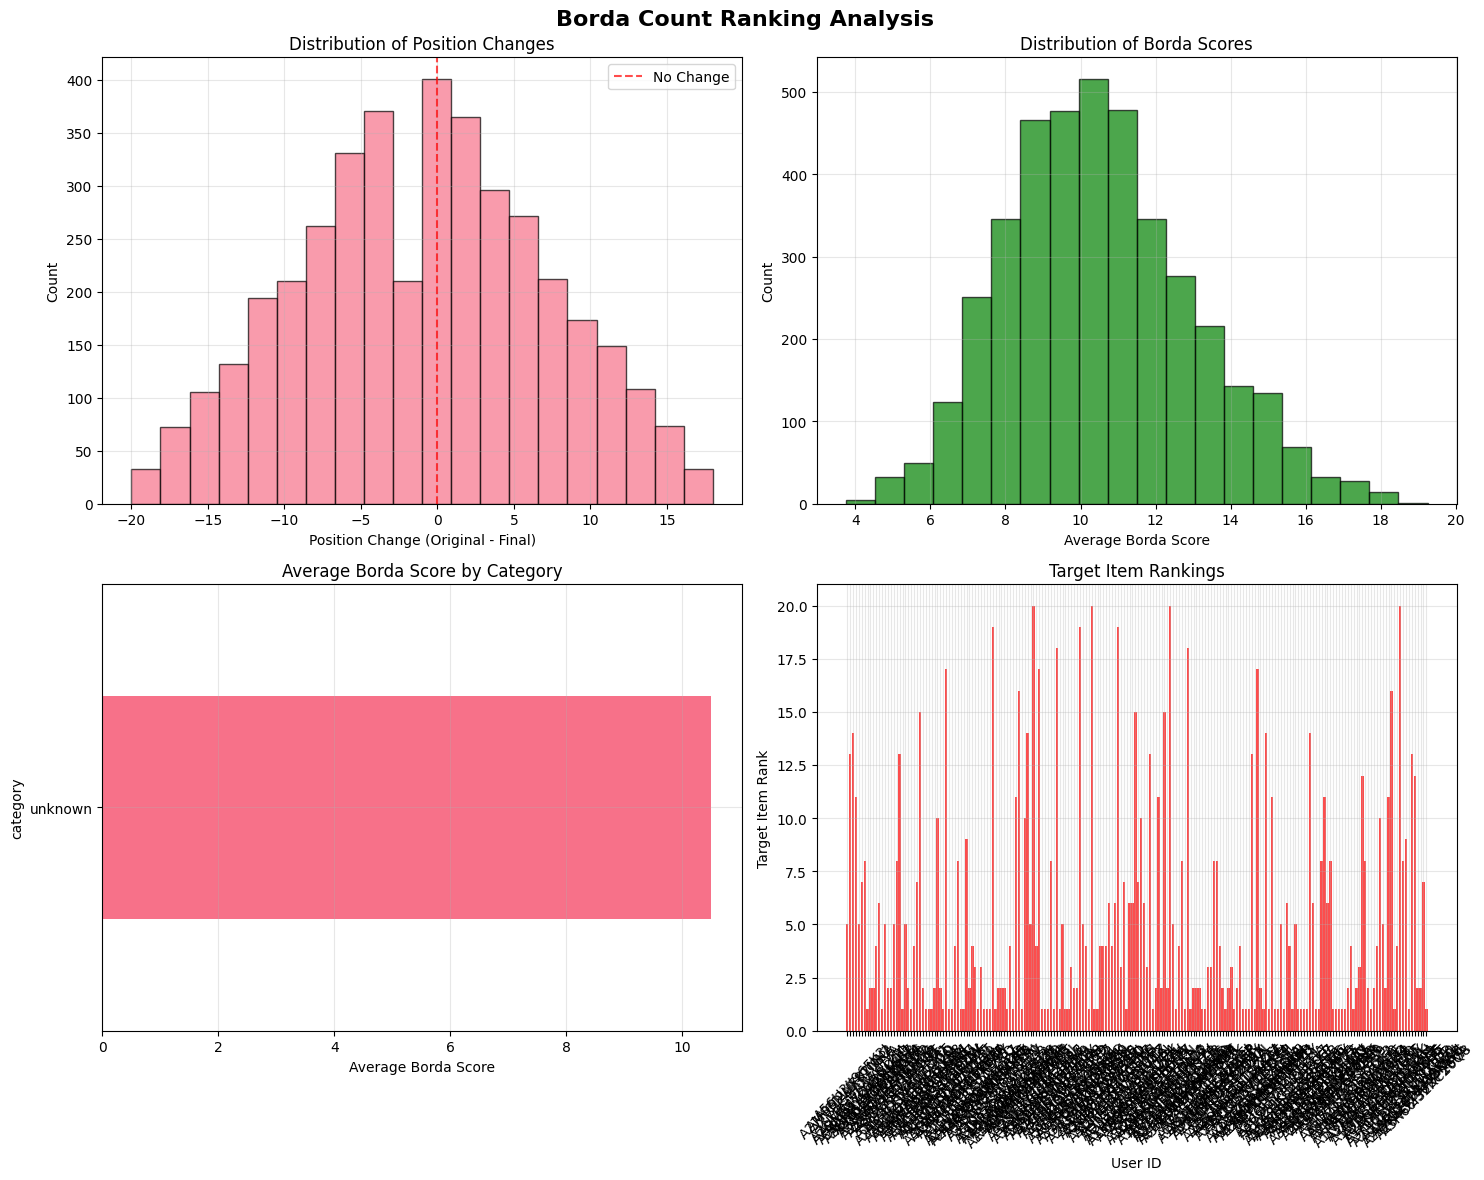

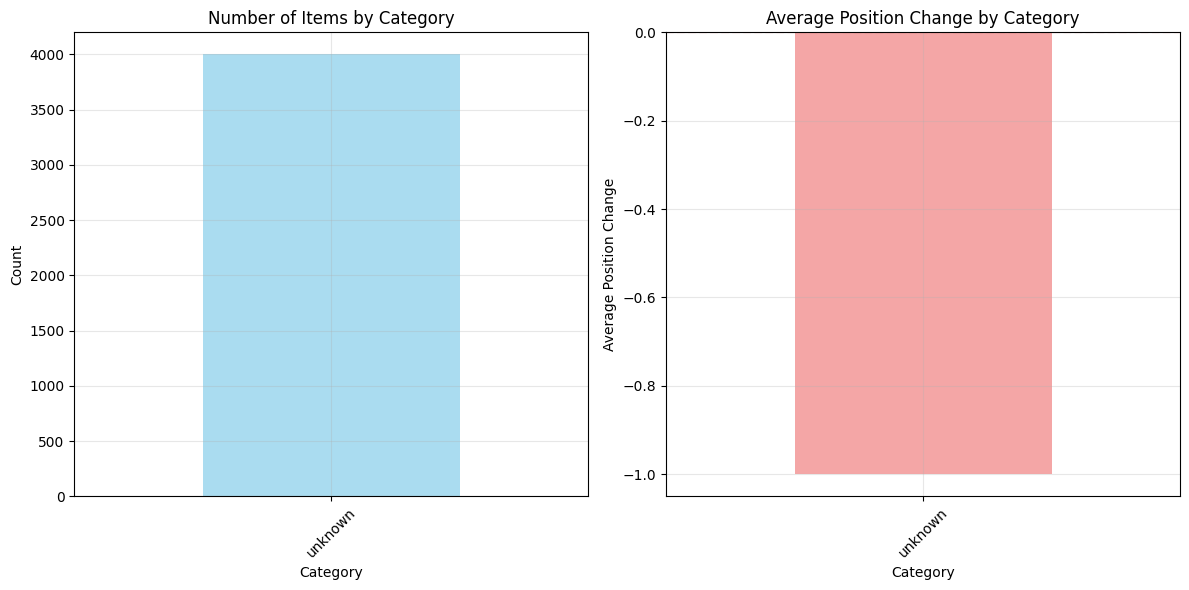

In [53]:
def create_visualizations(df_results, analysis):
    """
    Create comprehensive visualizations of Borda count results
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Borda Count Ranking Analysis', fontsize=16, fontweight='bold')
    
    # 1. Position Change Distribution
    axes[0, 0].hist(df_results['position_change'], bins=20, alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='No Change')
    axes[0, 0].set_xlabel('Position Change (Original - Final)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Distribution of Position Changes')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Borda Score Distribution
    axes[0, 1].hist(df_results['average_borda_score'], bins=20, alpha=0.7, edgecolor='black', color='green')
    axes[0, 1].set_xlabel('Average Borda Score')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Distribution of Borda Scores')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Category Performance
    category_scores = df_results.groupby('category')['average_borda_score'].mean().sort_values(ascending=True)
    category_scores.plot(kind='barh', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Average Borda Score')
    axes[1, 0].set_title('Average Borda Score by Category')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Target Item Performance
    target_data = df_results[df_results['is_target'] == True]
    if not target_data.empty:
        axes[1, 1].bar(target_data['user_id'], target_data['final_borda_rank'], alpha=0.7, color='red')
        axes[1, 1].set_xlabel('User ID')
        axes[1, 1].set_ylabel('Target Item Rank')
        axes[1, 1].set_title('Target Item Rankings')
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'No Target Items Found', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Target Item Rankings')
    
    plt.tight_layout()
    plt.show()
    
    # Category analysis chart
    plt.figure(figsize=(12, 6))
    
    # Count of items by category
    category_counts = df_results['category'].value_counts()
    
    plt.subplot(1, 2, 1)
    category_counts.plot(kind='bar', color='skyblue', alpha=0.7)
    plt.title('Number of Items by Category')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Average position change by category
    plt.subplot(1, 2, 2)
    category_changes = df_results.groupby('category')['position_change'].mean().sort_values()
    category_changes.plot(kind='bar', color='lightcoral', alpha=0.7)
    plt.title('Average Position Change by Category')
    plt.xlabel('Category')
    plt.ylabel('Average Position Change')
    plt.xticks(rotation=45)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create visualizations
print("🎨 Creating visualizations...")
create_visualizations(df_results, analysis)

In [54]:
def generate_enhanced_target_statistics(df_results, analysis):
    """
    Generate enhanced statistical summary with detailed target item top-position analysis
    """
    print("📊 ENHANCED STATISTICAL SUMMARY")
    print("="*60)
    
    # Overall statistics
    print("\n🔍 OVERALL STATISTICS:")
    print(f"   Total items analyzed: {len(df_results)}")
    print(f"   Number of users: {df_results['user_id'].nunique()}")
    print(f"   Number of categories: {df_results['category'].nunique()}")
    print(f"   Average Borda score: {df_results['average_borda_score'].mean():.2f} ± {df_results['average_borda_score'].std():.2f}")
    
    # Enhanced Target Item Performance
    target_items = df_results[df_results['is_target'] == True]
    if not target_items.empty:
        print(f"\n🎯 DETAILED TARGET ITEM PERFORMANCE:")
        print(f"   Total target items: {len(target_items)}")
        print(f"   Average target item rank: {target_items['final_borda_rank'].mean():.1f}")
        print(f"   Median target item rank: {target_items['final_borda_rank'].median():.1f}")
        print(f"   Best target item rank: {target_items['final_borda_rank'].min()}")
        print(f"   Worst target item rank: {target_items['final_borda_rank'].max()}")
        
        # Top position breakdown
        print(f"\n   📍 TOP POSITION BREAKDOWN:")
        print(f"      Target items at rank 1: {(target_items['final_borda_rank'] == 1).sum()}")
        print(f"      Target items in top 2: {(target_items['final_borda_rank'] <= 2).sum()}")
        print(f"      Target items in top 3: {(target_items['final_borda_rank'] <= 3).sum()}")
        print(f"      Target items in top 5: {(target_items['final_borda_rank'] <= 5).sum()}")
        print(f"      Target items in top 10: {(target_items['final_borda_rank'] <= 10).sum()}")
        
        # Percentage breakdown
        total_targets = len(target_items)
        print(f"\n   📊 PERCENTAGE BREAKDOWN:")
        print(f"      % at rank 1: {(target_items['final_borda_rank'] == 1).sum() / total_targets * 100:.1f}%")
        print(f"      % in top 2: {(target_items['final_borda_rank'] <= 2).sum() / total_targets * 100:.1f}%")
        print(f"      % in top 3: {(target_items['final_borda_rank'] <= 3).sum() / total_targets * 100:.1f}%")
        print(f"      % in top 5: {(target_items['final_borda_rank'] <= 5).sum() / total_targets * 100:.1f}%")
        print(f"      % in top 10: {(target_items['final_borda_rank'] <= 10).sum() / total_targets * 100:.1f}%")
        
        # Target item position changes
        print(f"\n   📈 TARGET ITEM POSITION CHANGES:")
        print(f"      Average position change: {target_items['position_change'].mean():.2f}")
        print(f"      Median position change: {target_items['position_change'].median():.2f}")
        print(f"      Target items that moved up: {(target_items['position_change'] > 0).sum()}")
        print(f"      Target items that moved down: {(target_items['position_change'] < 0).sum()}")
        print(f"      Target items that stayed same: {(target_items['position_change'] == 0).sum()}")
        
        # Best performing target items
        print(f"\n   🏆 BEST PERFORMING TARGET ITEMS:")
        top_targets = target_items.nsmallest(5, 'final_borda_rank')[['title', 'final_borda_rank', 'average_borda_score', 'position_change']]
        for idx, row in top_targets.iterrows():
            print(f"      Rank {row['final_borda_rank']}: {row['title'][:60]}...")
            print(f"         Borda Score: {row['average_borda_score']:.3f}, Position Change: {row['position_change']:+.0f}")
    
    # Position change statistics for all items
    print(f"\n📈 OVERALL POSITION CHANGE STATISTICS:")
    print(f"   Average position change: {df_results['position_change'].mean():.2f}")
    print(f"   Median position change: {df_results['position_change'].median():.2f}")
    print(f"   Items that moved up: {(df_results['position_change'] > 0).sum()}")
    print(f"   Items that moved down: {(df_results['position_change'] < 0).sum()}")
    print(f"   Items that stayed same: {(df_results['position_change'] == 0).sum()}")
    
    # Category performance
    print(f"\n📂 CATEGORY PERFORMANCE:")
    category_stats = df_results.groupby('category').agg({
        'average_borda_score': ['mean', 'std', 'count'],
        'position_change': 'mean'
    }).round(2)
    
    category_stats.columns = ['Avg_Borda_Score', 'Std_Borda_Score', 'Item_Count', 'Avg_Position_Change']
    category_stats = category_stats.sort_values('Avg_Borda_Score', ascending=False)
    
    print(category_stats)
    
    # Correlation analysis
    print(f"\n🔗 CORRELATION ANALYSIS:")
    correlations = df_results[['average_borda_score', 'original_position', 'position_change', 'original_ndcg_5']].corr()
    print(correlations.round(3))

# # Save all results
# save_comprehensive_results(borda_results, df_results, analysis)
generate_enhanced_target_statistics(df_results, analysis)
print("\n🎉 BORDA COUNT ANALYSIS COMPLETE!")
print("   All results have been processed, analyzed, and saved.")
print("   Check the generated files for detailed results.")

📊 ENHANCED STATISTICAL SUMMARY

🔍 OVERALL STATISTICS:
   Total items analyzed: 4000
   Number of users: 200
   Number of categories: 1
   Average Borda score: 10.50 ± 2.48

🎯 DETAILED TARGET ITEM PERFORMANCE:
   Total target items: 200
   Average target item rank: 5.2
   Median target item rank: 3.0
   Best target item rank: 1
   Worst target item rank: 20

   📍 TOP POSITION BREAKDOWN:
      Target items at rank 1: 65
      Target items in top 2: 96
      Target items in top 3: 105
      Target items in top 5: 135
      Target items in top 10: 166

   📊 PERCENTAGE BREAKDOWN:
      % at rank 1: 32.5%
      % in top 2: 48.0%
      % in top 3: 52.5%
      % in top 5: 67.5%
      % in top 10: 83.0%

   📈 TARGET ITEM POSITION CHANGES:
      Average position change: 4.96
      Median position change: 5.00
      Target items that moved up: 143
      Target items that moved down: 47
      Target items that stayed same: 10

   🏆 BEST PERFORMING TARGET ITEMS:
      Rank 1: New Atkins for a New Y